<a href="https://colab.research.google.com/github/magdaferreira71-arch/miniature-lamp/blob/main/vendas_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== DADOS DE VENDAS =====
    id_venda  data_venda    produto    categoria  valor_venda
0          1  2023-01-01  Produto A  Eletrônicos       1500.0
1          2  2023-01-05  Produto B       Roupas        350.0
2          3  2023-02-10  Produto C  Eletrônicos       1200.0
3          4  2023-03-15  Produto D       Livros        200.0
4          5  2023-03-20  Produto E  Eletrônicos        800.0
5          6  2023-04-02  Produto F       Roupas        400.0
6          7  2023-05-05  Produto G       Livros        150.0
7          8  2023-06-10  Produto H  Eletrônicos       1000.0
8          9  2023-07-20  Produto I       Roupas        600.0
9         10  2023-08-25  Produto J  Eletrônicos        700.0
10        11  2023-09-30  Produto K       Livros        300.0
11        12  2023-10-05  Produto L       Roupas        450.0
12        13  2023-11-15  Produto M  Eletrônicos        900.0
13        14  2023-12-20  Produto N       Livros        250.0
14        15  2023-01-01  Produto A  Elet

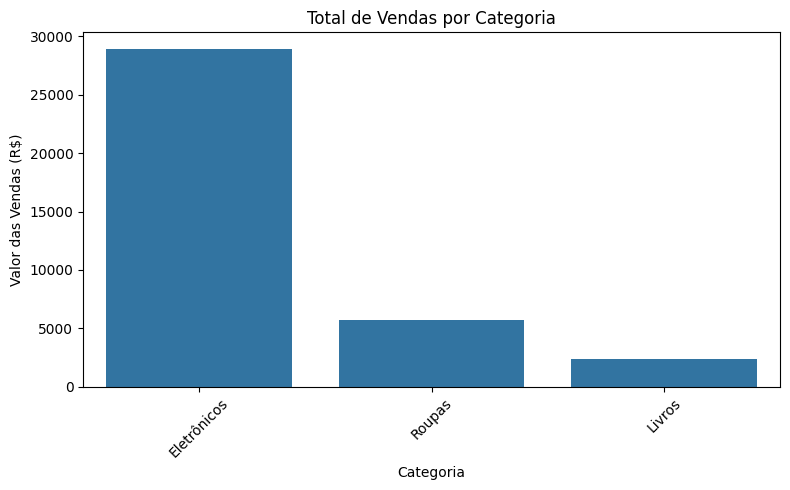

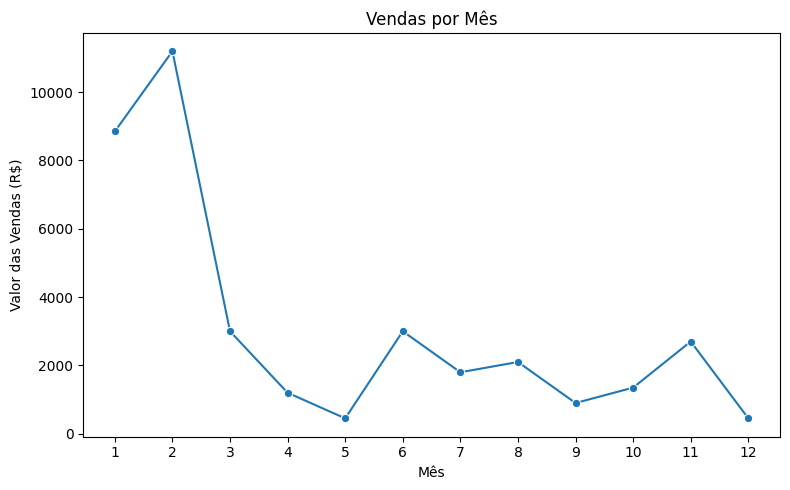

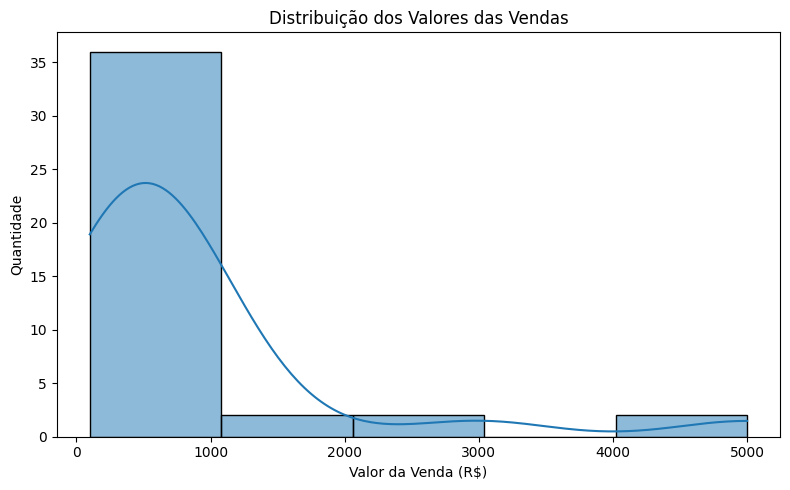


Programa finalizado!


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PASSO 1 - CONECTAR AO BANCO DE DADOS
conexao = sqlite3.connect("dados_vendas.db")
cursor = conexao.cursor()

# Criar tabela
cursor.execute("""
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
""")

# Inserir dados
dados = [
    ("2023-01-01", "Produto A", "Eletrônicos", 3000.00),
    ("2023-01-05", "Produto B", "Roupas", 500.00),
    ("2023-02-10", "Produto C", "Eletrônicos", 5000.00),
    ("2023-03-15", "Produto D", "Livros", 200.00),
    ("2023-03-20", "Produto E", "Eletrônicos", 800.00),
    ("2023-04-02", "Produto F", "Roupas", 400.00),
    ("2023-05-05", "Produto G", "Livros", 150.00),
    ("2023-06-10", "Produto H", "Eletrônicos", 1000.00),
    ("2023-07-20", "Produto I", "Roupas", 600.00),
    ("2023-08-25", "Produto J", "Eletrônicos", 700.00),
    ("2023-09-30", "Produto K", "Livros", 300.00),
    ("2023-10-05", "Produto L", "Roupas", 450.00),
    ("2023-11-15", "Produto M", "Eletrônicos", 900.00),
    ("2023-12-20", "Produto N", "Livros", 100.00)
]

cursor.executemany("""
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda)
VALUES (?, ?, ?, ?)
""", dados)
conexao.commit()

# PASSO 2 - CARREGAR OS DADOS
df_vendas = pd.read_sql_query(
    "SELECT * FROM vendas1", conexao
)

print("\n===== DADOS DE VENDAS =====")
print(df_vendas)

# Converter data
df_vendas["data_venda"] = pd.to_datetime(
    df_vendas["data_venda"]
)

# Verificar dados
print("\n===== INFORMAÇÕES =====")
print(df_vendas.info())

print("\n===== VALORES AUSENTES =====")
print(df_vendas.isnull().sum())

# PASSO 3 - ANÁLISE
# Total de vendas
total = df_vendas["valor_venda"].sum()
print("\n===== RESULTADOS =====")
print(f"Total de vendas: R$ {total:.2f}")

# Média
media = df_vendas["valor_venda"].mean()
print(f"Média por venda: R$ {media:.2f}")

# Maior venda
maior = df_vendas.loc[
    df_vendas["valor_venda"].idxmax()
]
print("\nMaior venda:")
print(maior)

# Vendas por categoria
vendas_categoria = df_vendas.groupby(
    "categoria"
)["valor_venda"].sum().sort_values(
    ascending=False
)
print("\n===== VENDAS POR CATEGORIA =====")
print(vendas_categoria)

# Vendas por mês
df_vendas["mes"] = df_vendas[
    "data_venda"
].dt.month
vendas_mes = df_vendas.groupby(
    "mes"
)["valor_venda"].sum()
print("\n===== VENDAS POR MÊS =====")
print(vendas_mes)

# PASSO 4 - GRÁFICO POR CATEGORIA
plt.figure(figsize=(8, 5))
sns.barplot(
    x=vendas_categoria.index,
    y=vendas_categoria.values
)
plt.title("Total de Vendas por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Valor das Vendas (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# GRÁFICO POR MÊS
plt.figure(figsize=(8, 5))
sns.lineplot(
    x=vendas_mes.index,
    y=vendas_mes.values,
    marker="o"
)
plt.title("Vendas por Mês")
plt.xlabel("Mês")
plt.ylabel("Valor das Vendas (R$)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# HISTOGRAMA
plt.figure(figsize=(8, 5))
sns.histplot(
    df_vendas["valor_venda"],
    bins=5,
    kde=True
)
plt.title("Distribuição dos Valores das Vendas")
plt.xlabel("Valor da Venda (R$)")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

# Fechar banco
conexao.close()
print("\nPrograma finalizado!")